<a href="https://colab.research.google.com/github/Veritax0/BEV-vs-ICE/blob/main/sesiones_practicas/sp_2_Juan_Manuel_Vera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>


## <span style="color:black;"><strong>Datos de los estudiantes</strong></span>

In [ ]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

📝 Ingresa tu nombre completo: Juan Manuel Vera Osorio
📧 Ingresa tu correo electrónico: juan.verao@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de tu cédula: 416823


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

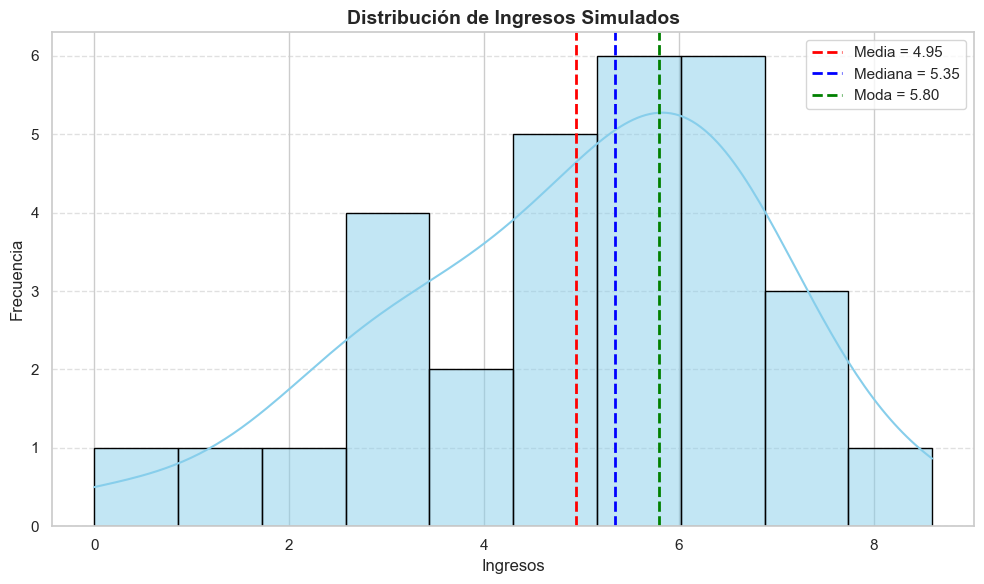

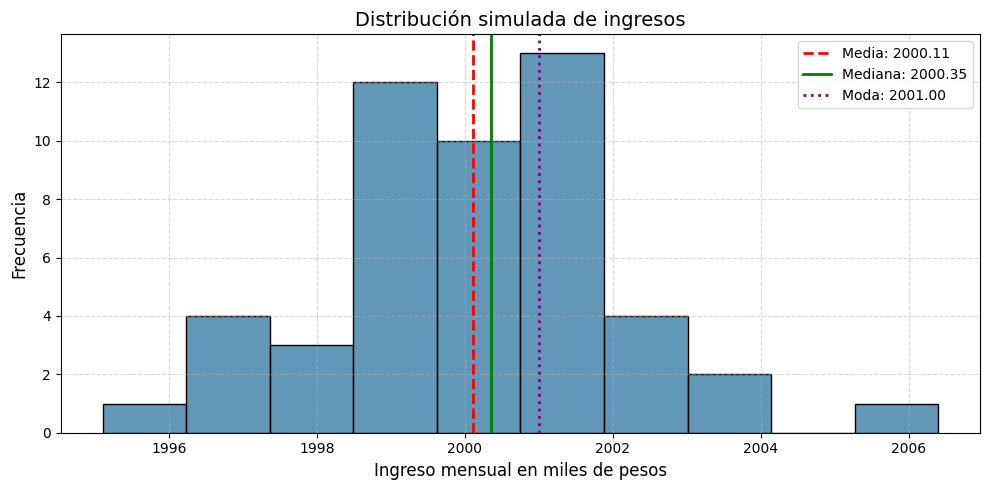

In [2]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Parámetros de la distribución
media_teorica = 2000
desviacion_estandar = 2
n_muestras = 50

# Fijar semilla para reproducibilidad
np.random.seed(416823)

# Generar muestra simulada
ingresos = np.random.normal(loc=media_teorica,
                            scale=desviacion_estandar,
                            size=n_muestras)

# Reemplazar valores negativos por 0
ingresos = np.where(ingresos < 0, 0, ingresos)
ingresos = np.round(ingresos,1)

# Medidas de tendencia central
media = np.mean(ingresos)
mediana = np.median(ingresos)
moda = stats.mode(ingresos, keepdims=True)[0][0]

# Graficar histograma
plt.figure(figsize=(10, 5))
sns.histplot(ingresos, bins=10, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

plt.title("Distribución simulada de ingresos", fontsize=14)
plt.xlabel("Ingreso mensual en miles de pesos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
ingresos

array([2001.7, 1998.5, 2000.7, 2000.3, 2001. , 2004. , 1996.8, 2001.1,
       1996.4, 1999. , 2006.4, 2002.9, 2000.9, 2001. , 2001. , 2001.6,
       2001. , 1999.4, 1998.9, 2000.9, 2001.1, 1998.7, 1997.9, 2000.4,
       1999.9, 1995.1, 2000.8, 2000.6, 1996.4, 2003.6, 1999.5, 1998.3,
       2002.8, 2002.3, 1999.1, 1999.8, 1998.7, 1999.2, 1999.3, 1997. ,
       2002. , 2001.3, 1997.9, 2001.3, 2000.4, 2000. , 1998.9, 1999.3,
       2000.4, 1999.8])

### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

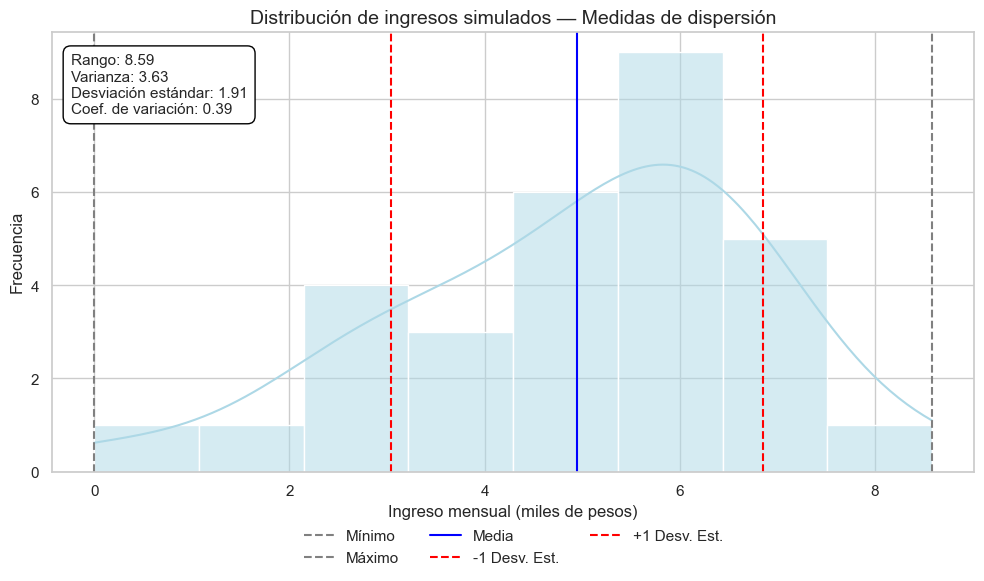

In [4]:
# Mostrar resultados
print("Muestra simulada de ingresos:\n")
print(ingresos)

print("\nEstadísticas muestrales:")
print(f"Media muestral: {np.mean(ingresos):.2f}")
print(f"Desviación estándar muestral: {np.std(ingresos, ddof=1):.2f}")

Muestra simulada de ingresos:

[2001.7 1998.5 2000.7 2000.3 2001.  2004.  1996.8 2001.1 1996.4 1999.
 2006.4 2002.9 2000.9 2001.  2001.  2001.6 2001.  1999.4 1998.9 2000.9
 2001.1 1998.7 1997.9 2000.4 1999.9 1995.1 2000.8 2000.6 1996.4 2003.6
 1999.5 1998.3 2002.8 2002.3 1999.1 1999.8 1998.7 1999.2 1999.3 1997.
 2002.  2001.3 1997.9 2001.3 2000.4 2000.  1998.9 1999.3 2000.4 1999.8]

Estadísticas muestrales:
Media muestral: 2000.11
Desviación estándar muestral: 2.05


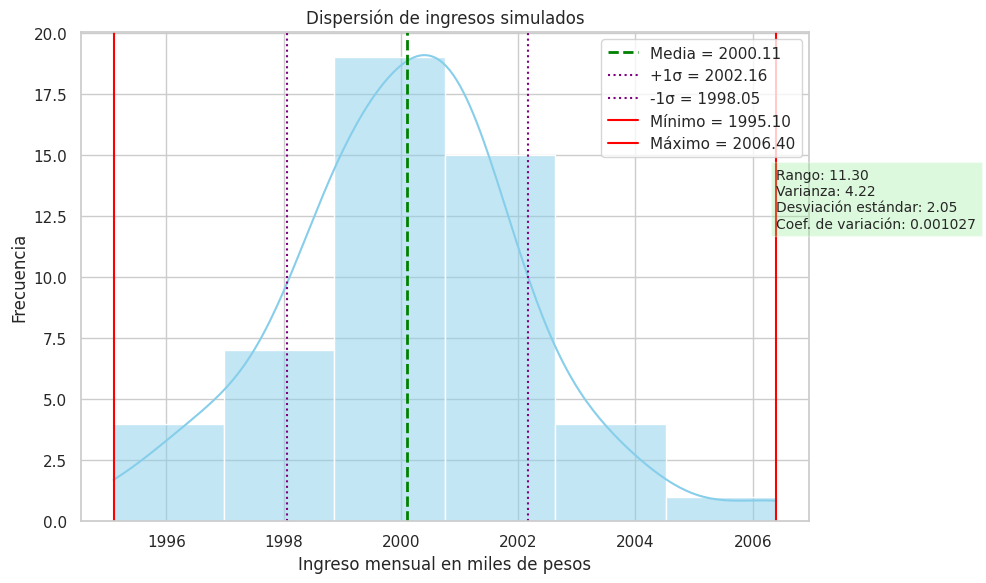

In [5]:
minimo = np.min(ingresos)
maximo = np.max(ingresos)
rango = maximo - minimo
varianza = np.var(ingresos, ddof=1)
desviacion = np.std(ingresos, ddof=1)
coef_var = desviacion / media

# Nueva visualización enfocada en dispersión
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(ingresos, bins=6, kde=True, color='skyblue')

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo:.2f}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo:.2f}')

plt.title("Dispersión de ingresos simulados")
plt.xlabel("Ingreso mensual en miles de pesos")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.6f}"
)

plt.text(maximo, plt.ylim()[1]*0.6, texto,
         bbox=dict(facecolor='lightgreen', alpha=0.3),
         fontsize=10)

plt.tight_layout()
plt.show()

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

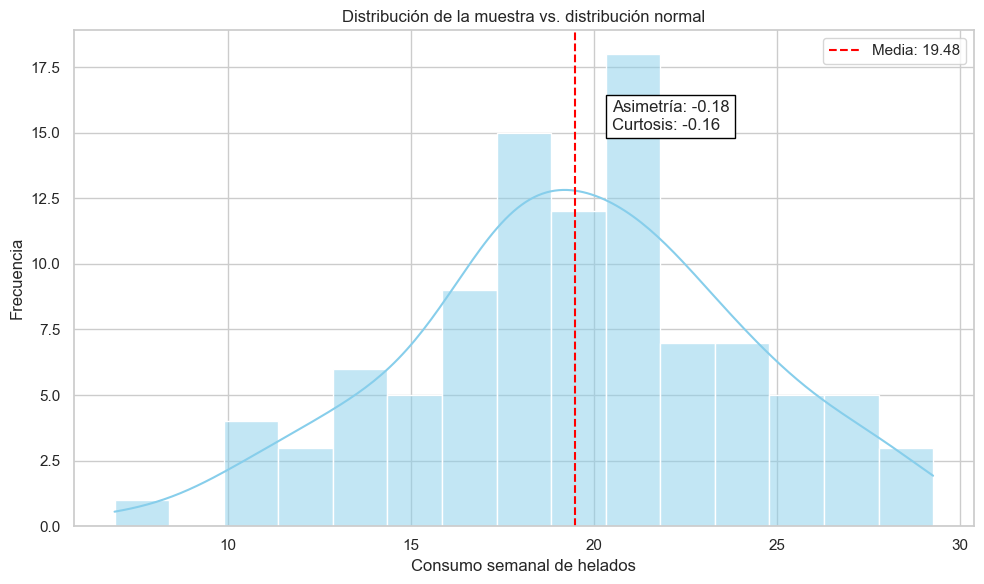


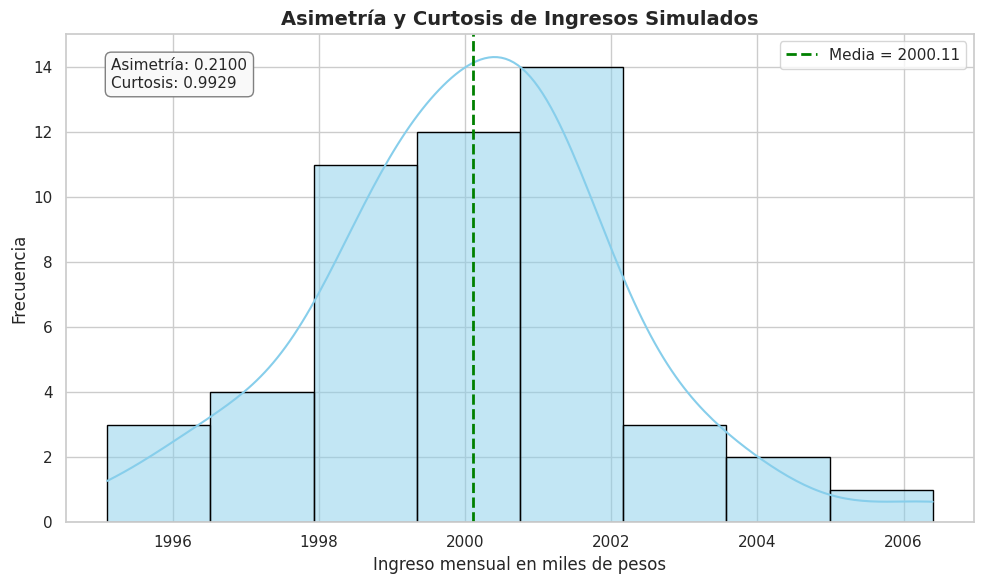

In [6]:
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid")

# Cálculo de medidas
asimetria = skew(ingresos)
curtosis_valor = kurtosis(ingresos, fisher=True)  # Fisher=True → normal = 0

# Visualización
plt.figure(figsize=(10, 6))

sns.histplot(ingresos, kde=True, bins=8, color='skyblue', edgecolor="black")

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')

plt.title("Asimetría y Curtosis de Ingresos Simulados", fontsize=14, fontweight='bold')
plt.xlabel("Ingreso mensual en miles de pesos")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro informativo
plt.text(0.05, 0.95,
         f"Asimetría: {asimetria:.4f}\nCurtosis: {curtosis_valor:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9", edgecolor="gray"))

plt.tight_layout()
plt.show()

La gráfica muestra la distribución de los ingresos simulados junto con una curva de distribución normal para facilitar la comparación. La asimetría obtenida es 0.21, lo que indica una ligera inclinación hacia la derecha, es decir, existen algunos valores de ingresos más altos que desplazan levemente la cola de la distribución hacia ese lado. Sin embargo, el valor es cercano a cero, por lo que la podríamos considerar como una distribución simétrica.

Por otro lado, la curtosis es 0.99, lo que sugiere una distribución ligeramente leptocúrtica, caracterizada por una mayor concentración de datos alrededor de la media y colas un poco más pronunciadas que en una distribución normal. A pesar de ello, el histograma sigue una forma bastante cercana a la curva normal superpuesta, lo que indica que los datos simulados presentan un comportamiento de una distribución normal, con leves desviaciones en su forma.

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

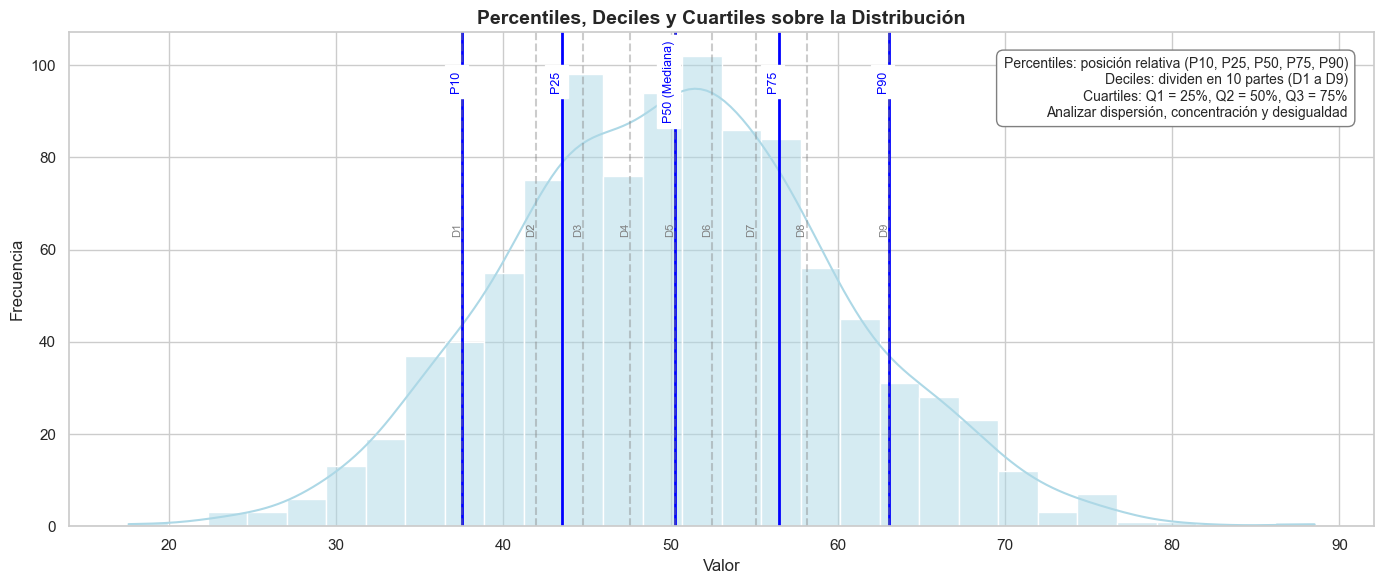

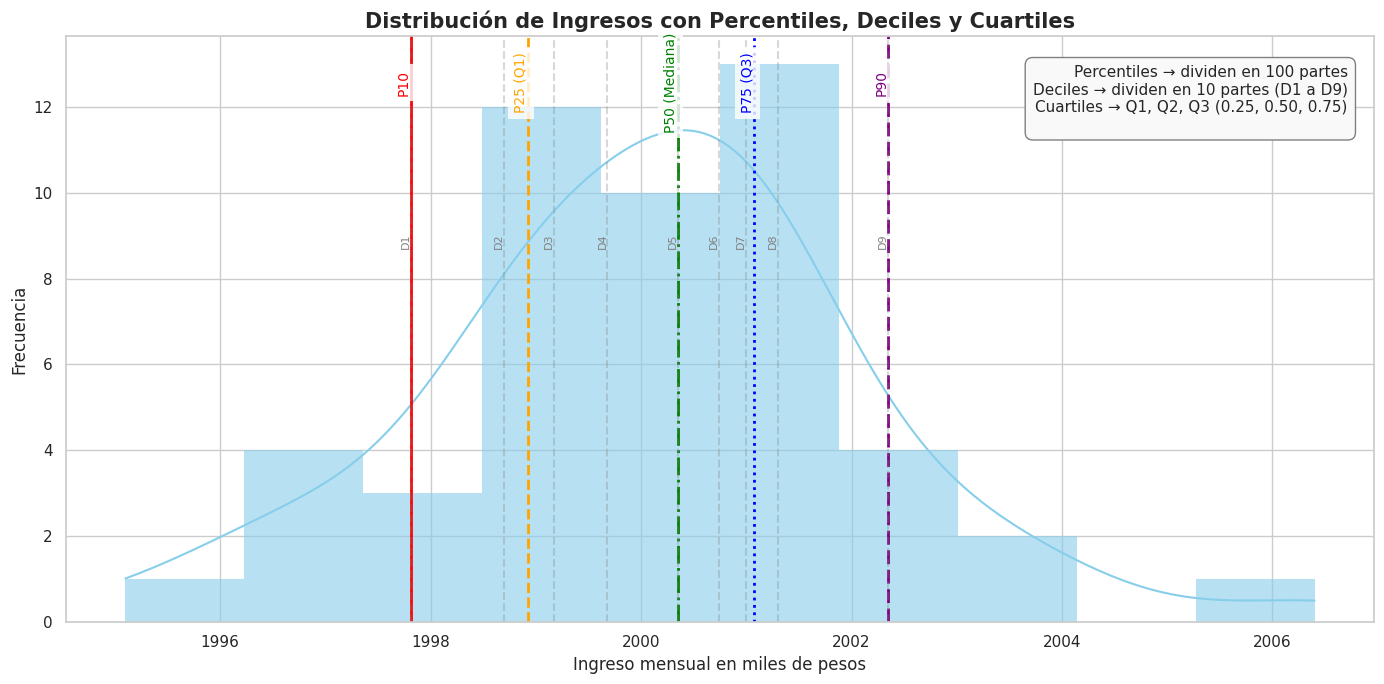

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Cálculo de percentiles clave (incluye cuartiles y mediana)
percentiles = {
    'P10': {'valor': np.percentile(ingresos, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(ingresos, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(ingresos, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(ingresos, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(ingresos, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(ingresos, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 7))
sns.histplot(ingresos, kde=True, color='skyblue', bins=10, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

# Recuadro explicativo
texto = (
    "Percentiles → dividen en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n"
)
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

plt.title("Distribución de Ingresos con Percentiles, Deciles y Cuartiles", fontsize=15, fontweight='bold')
plt.xlabel("Ingreso mensual en miles de pesos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

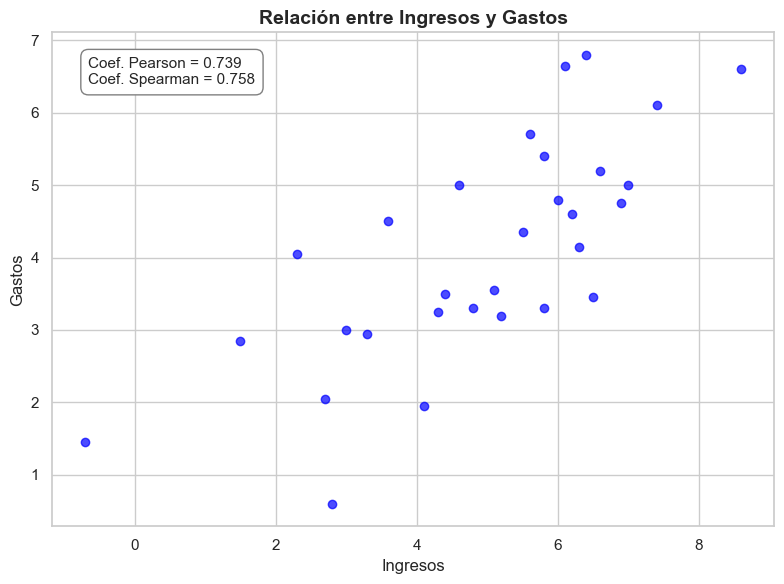

Semilla (6 últimos dígitos): 416823
Pearson:  -0.148
Spearman: -0.204


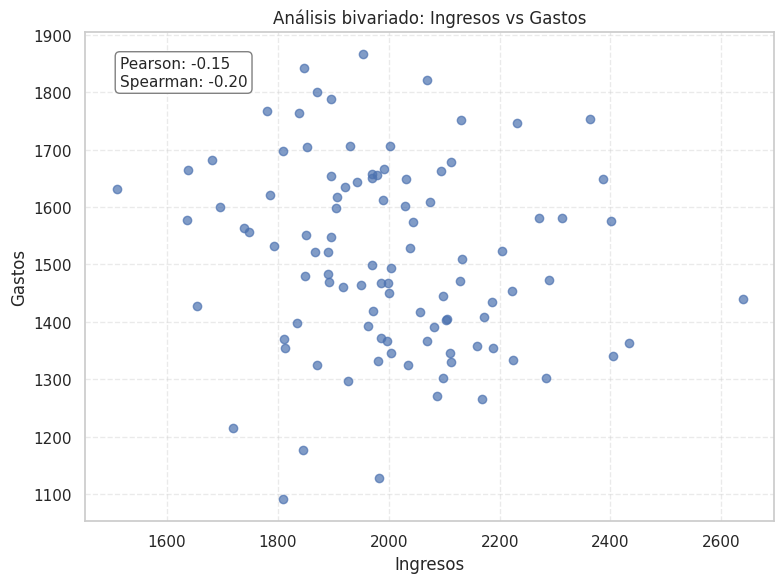


Resumen descriptivo:

   Variable    Media  Desv. Est.
0  Ingresos  1999.68      193.76
1    Gastos  1511.61      164.41


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# 1) Base: 6 últimos dígitos de tu cédula (cámbialo por los tuyos)
cedula = 416823

# 2) Semilla reproducible
np.random.seed(cedula)
n = 100

# 3) Generar dos variables normales (ej: ingresos y gastos)
ingresos = np.random.normal(loc=2000, scale=200, size=n)
gastos = np.random.normal(loc=1500, scale=180, size=n)

# 5) Correlaciones
pearson, _ = stats.pearsonr(ingresos, gastos)
spearman, _ = stats.spearmanr(ingresos, gastos)

print(f"Semilla (6 últimos dígitos): {cedula}")
print(f"Pearson:  {pearson:.3f}")
print(f"Spearman: {spearman:.3f}")

# 6) Gráfico bivariado (scatter) + caja con coeficientes
plt.figure(figsize=(8, 6))
plt.scatter(ingresos, gastos, alpha=0.7)
plt.title("Análisis bivariado: Ingresos vs Gastos")
plt.xlabel("Ingresos")
plt.ylabel("Gastos")

plt.text(0.05, 0.95, f"Pearson: {pearson:.2f}\nSpearman: {spearman:.2f}",
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 7) Tabla resumen
df = pd.DataFrame({
    "Variable": ["Ingresos", "Gastos"],
    "Media": [np.mean(ingresos), np.mean(gastos)],
    "Desv. Est.": [np.std(ingresos, ddof=1), np.std(gastos, ddof=1)]
})

print("\nResumen descriptivo:\n")
print(df.round(2))

### Interpretación del análisis bivariado: Ingresos vs Gastos

El gráfico de dispersión muestra cómo se distribuyen los valores de **ingresos** y **gastos** para cada observación. Los puntos aparecen bastante dispersos en el plano, sin formar una línea o patrón claro que indique que cuando una variable aumenta la otra también lo hace de forma consistente.

El coeficiente de **correlación de Pearson (0.15)** es cercano a cero, lo que indica que la relación lineal entre ingresos y gastos es **muy baja**. Esto significa que, aunque en algunos casos los gastos aumentan cuando los ingresos son mayores, este comportamiento no se observa de manera consistente en toda la muestra.

El coeficiente de **Spearman (-0.20)** también tiene un valor cercano a cero, lo que refuerza la idea de que **no existe una tendencia clara en la forma en que los datos se ordenan**. En otras palabras, al comparar los valores más altos y más bajos de ingresos con los de gastos, no se identifica un patrón estable entre ambas variables.

En conjunto, tanto la distribución visual de los puntos en el gráfico como los valores de las correlaciones sugieren que **los ingresos y los gastos no presentan una relación fuerte en esta muestra simulada**, lo cual es esperado ya que ambas variables fueron generadas aleatoriamente a partir de distribuciones normales independientes.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

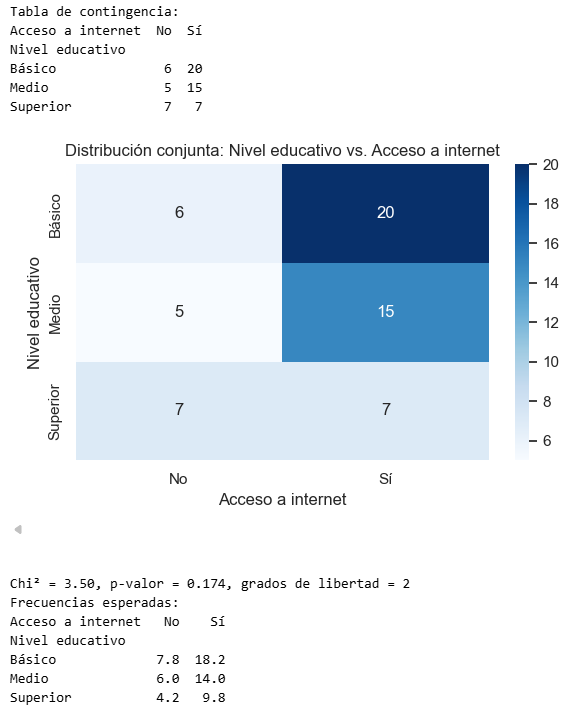

Tabla de contingencia:

Acceso a internet  No  Sí
Nivel educativo          
Básico              6  15
Medio               6  18
Superior            1  14

Chi² = 2.74, p-valor = 0.255, grados de libertad = 2

Frecuencias esperadas:

Acceso a internet   No    Sí
Nivel educativo             
Básico             4.6  16.4
Medio              5.2  18.8
Superior           3.2  11.8


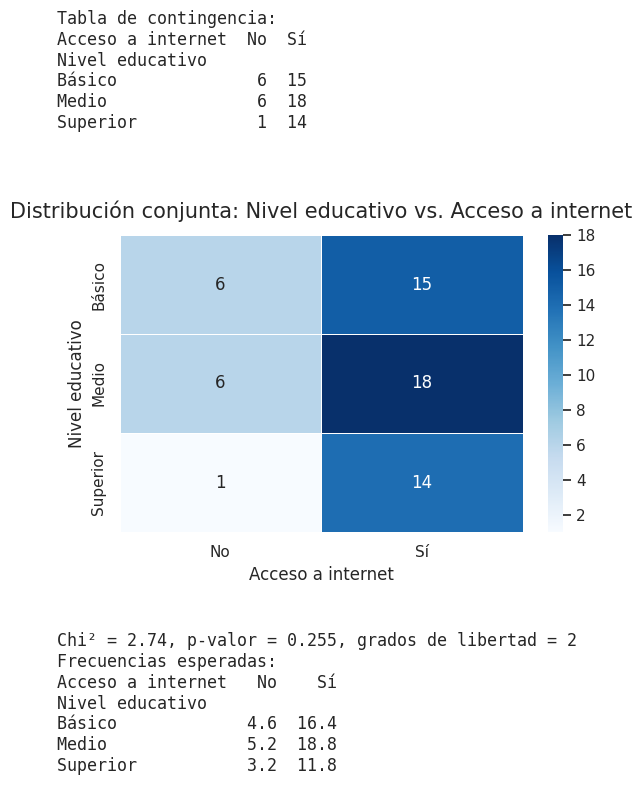

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1) Semilla reproducible (cambia por tus 6 últimos dígitos)
cedula_ult6 = 416823
np.random.seed(cedula_ult6)

# 2) Simular muestra
n = 60
niveles = ["Básico", "Medio", "Superior"]

# Nivel educativo
nivel_educativo = np.random.choice(niveles, size=n, p=[0.35, 0.40, 0.25])

# Acceso a internet con probabilidades dependientes del nivel
prob_si = {"Básico": 0.65, "Medio": 0.80, "Superior": 0.92}
acceso_internet = np.array([
    "Sí" if np.random.rand() < prob_si[niv] else "No"
    for niv in nivel_educativo
])

df = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

# 3) Tabla de contingencia
tabla = pd.crosstab(df["Nivel educativo"], df["Acceso a internet"])

# Asegurar orden de filas y columnas
tabla = tabla.reindex(index=["Básico", "Medio", "Superior"], columns=["No", "Sí"], fill_value=0)

print("Tabla de contingencia:\n")
print(tabla)

# 4) Prueba Chi-cuadrado
chi2, p, dof, esperadas = chi2_contingency(tabla)

print(f"\nChi² = {chi2:.2f}, p-valor = {p:.3f}, grados de libertad = {dof}")

frecuencias_esperadas = pd.DataFrame(
    esperadas,
    index=tabla.index,
    columns=tabla.columns
)

print("\nFrecuencias esperadas:\n")
print(frecuencias_esperadas.round(1))

# 5) Gráfica tipo imagen: tabla arriba + heatmap + texto abajo
sns.set_theme(style="white")
fig = plt.figure(figsize=(7, 9))

# Texto superior con la tabla
texto_tabla = "Tabla de contingencia:\n"
texto_tabla += tabla.to_string()

fig.text(
    0.03, 0.96, texto_tabla,
    ha="left", va="top",
    fontsize=12, family="monospace"
)

# Heatmap central
ax = fig.add_axes([0.12, 0.38, 0.72, 0.33])
sns.heatmap(
    tabla,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Distribución conjunta: Nivel educativo vs. Acceso a internet", fontsize=15, pad=12)
ax.set_xlabel("Acceso a internet")
ax.set_ylabel("Nivel educativo")

# Texto inferior con chi², p y frecuencias esperadas
texto_inferior = (
    f"Chi² = {chi2:.2f}, p-valor = {p:.3f}, grados de libertad = {dof}\n"
    f"Frecuencias esperadas:\n"
    f"{frecuencias_esperadas.round(1).to_string()}"
)

fig.text(
    0.03, 0.11, texto_inferior,
    ha="left", va="bottom",
    fontsize=12, family="monospace"
)

plt.show()

### Interpretación de la prueba Chi-Cuadrado

La tabla de contingencia y el mapa de calor muestran la distribución conjunta entre **nivel educativo** y **acceso a internet** en la muestra simulada de 60 personas. En términos generales, se observa que la mayoría de las personas en todos los niveles educativos reportan **tener acceso a internet**, aunque esta proporción parece aumentar ligeramente en el nivel **superior**, donde casi todos los individuos tienen acceso.

Para evaluar si esta diferencia puede considerarse estadísticamente significativa, se aplicó la **prueba Chi-cuadrado de independencia**, obteniendo un valor de **χ² = 2.74** con **2 grados de libertad** y un **p-valor = 0.255**.

Dado que el **p-valor es mayor que 0.05**, no se puede rechazar la hipótesis nula de independencia entre las variables. Esto significa que, **con los datos de esta muestra simulada, no hay evidencia estadística suficiente para afirmar que el nivel educativo esté asociado con el acceso a internet**.

Aunque visualmente se observa que los niveles educativos más altos presentan más casos con acceso a internet, esta diferencia puede explicarse por **variación aleatoria de la muestra**, y no necesariamente por una relación estadística real entre las variables.

## <span style="color:black;"><strong>Parte 3: Análisis Multivariado</strong></span>

In [10]:
# Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import shutil
import seaborn as sns

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Datos
# Importar datos desde Kaggle y guardar en data
import kagglehub
ev_vs_petrol = kagglehub.dataset_download('aryanmdev/will-evs-replace-petrol-cars')

print('Data source import complete.')

# Ruta del directorio que descargaste con kagglehub
origen = ev_vs_petrol

# Crear carpeta destino si no existe
carpeta_destino = 'data'
os.makedirs(carpeta_destino, exist_ok=True)

# Lista de los nombres exactos de los CSV que quieres mover
archivos_a_mover = ['ev_vs_petrol_dataset_v3.csv']

# Mover cada archivo
for archivo in archivos_a_mover:
    origen_archivo = os.path.join(origen, archivo)
    destino_archivo = os.path.join(carpeta_destino, archivo)
    shutil.copy(origen_archivo, destino_archivo)
    print(f"{archivo} copiado a {carpeta_destino}/")

print("\Todos los archivos han sido copiados con éxito.")

# Crear dataset
df = pd.read_csv("data/ev_vs_petrol_dataset_v3.csv")

<>:39: SyntaxWarning: invalid escape sequence '\T'
<>:39: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_439/572402606.py:39: SyntaxWarning: invalid escape sequence '\T'
  print("\Todos los archivos han sido copiados con éxito.")


100%|██████████| 38.6k/38.6k [00:00<00:00, 26.9MB/s]

Extracting files...
Data source import complete.
ev_vs_petrol_dataset_v3.csv copiado a data/
\Todos los archivos han sido copiados con éxito.


<Figure size 1200x600 with 0 Axes>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# 1. Selección y preparación de variables
# ============================================================

variables_modelo = [
    "gdp_per_capita",
    "ev_subsidy_usd",
    "fuel_price_usd_per_liter",
    "electricity_price_usd_per_kwh",
    "charging_stations",
    "fast_chargers_share",
    "emission_regulation_score",
    "urban_population_percent"
]

variable_objetivo = "ev_market_share"

columnas_necesarias = [variable_objetivo] + variables_modelo
df_modelo = df[columnas_necesarias].dropna().copy()

# Transformación logarítmica para infraestructura por su alta dispersión
df_modelo["charging_stations_log"] = np.log1p(df_modelo["charging_stations"])
df_modelo = df_modelo.drop(columns=["charging_stations"])

variables_finales = [
    "gdp_per_capita",
    "ev_subsidy_usd",
    "fuel_price_usd_per_liter",
    "electricity_price_usd_per_kwh",
    "charging_stations_log",
    "fast_chargers_share",
    "emission_regulation_score",
    "urban_population_percent"
]

X = df_modelo[variables_finales]
y = df_modelo[variable_objetivo]

X_const = sm.add_constant(X)
modelo = sm.OLS(y, X_const).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        ev_market_share   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     144.8
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          8.13e-170
Time:                        03:43:05   Log-Likelihood:                -4393.7
No. Observations:                1200   AIC:                             8805.
Df Residuals:                    1191   BIC:                             8851.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         


[1] Gráfico: valores reales vs valores ajustados


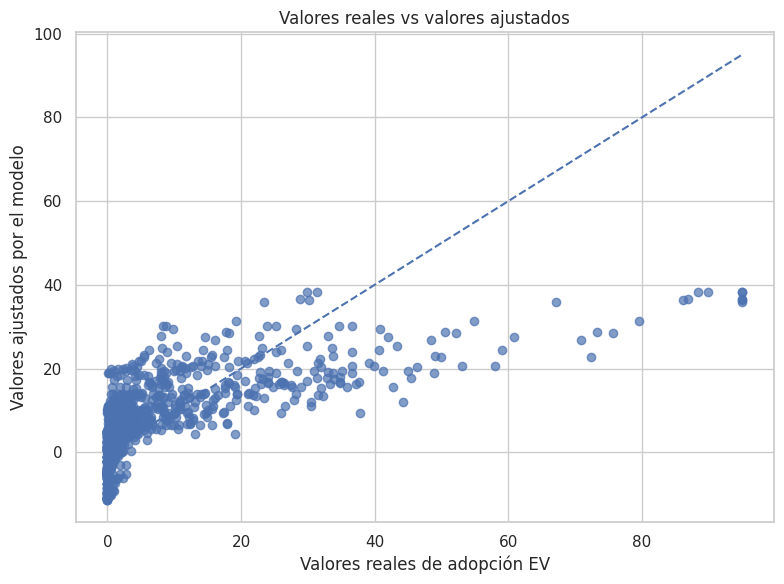

In [12]:
print("\n[1] Gráfico: valores reales vs valores ajustados")

plt.figure(figsize=(8, 6))
plt.scatter(y, modelo.fittedvalues, alpha=0.7)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)
plt.title("Valores reales vs valores ajustados")
plt.xlabel("Valores reales de adopción EV")
plt.ylabel("Valores ajustados por el modelo")
plt.tight_layout()
plt.show()

El gráfico muestra que el modelo logra capturar la tendencia general, pero presenta alta dispersión en valores altos de adopción.

Esto indica que podrían existir factores adicionales no incluidos en el modelo, algunas variables originales podrían estar capturando información similar

Esto podría deberse a que algunas de las variables economicas tienden moverse hacia los mismos valores países más desarrollados.


[2] Gráfico: residuos vs valores ajustados


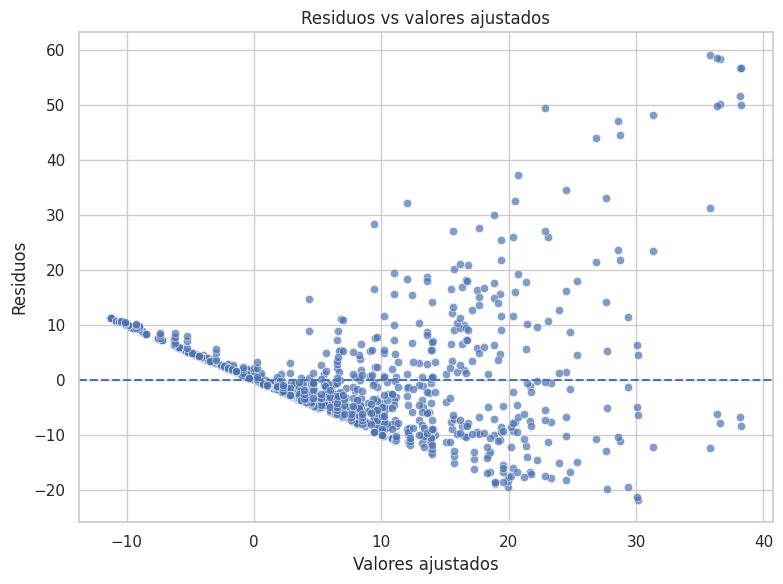

In [13]:
print("\n[2] Gráfico: residuos vs valores ajustados")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=modelo.fittedvalues, y=modelo.resid, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residuos vs valores ajustados")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.tight_layout()
plt.show()

In [ ]:
En este grafico se observa que la dispersión de los residuos aumenta con los valores ajustados, lo que podría indicar heterocedasticidad, personalmente pienso esto se debe a que las distribuciónes de mercado altas son pocas muestras y se concentran en paises con las mismas tendencias economicas, es decir, varias variables describen el mismo fenomeno estructural


[3] Gráfico: histograma de residuos


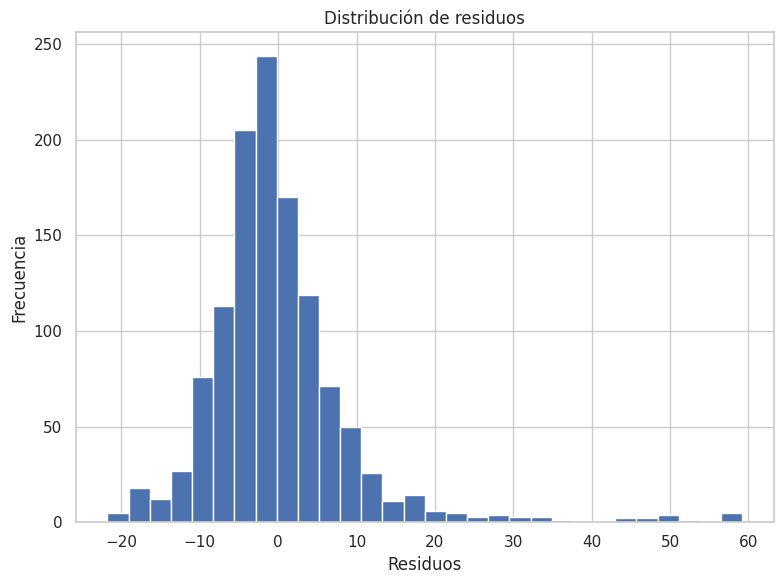

In [14]:
print("\n[3] Gráfico: histograma de residuos")

plt.figure(figsize=(8, 6))
plt.hist(modelo.resid, bins=30)
plt.title("Distribución de residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

El histograma muestra que los residuos se concentran alrededor de cero, lo cual es positivo, pero existe asimetría hacia valores positivos grandes.

Esto indica que el modelo subestima algunos casos de alta adopción, esto también puede sugerir que algunas variables del modelo no capturan completamente esas diferencias estructurales.



[4] Gráfico: Q-Q plot de residuos


<Figure size 800x600 with 0 Axes>

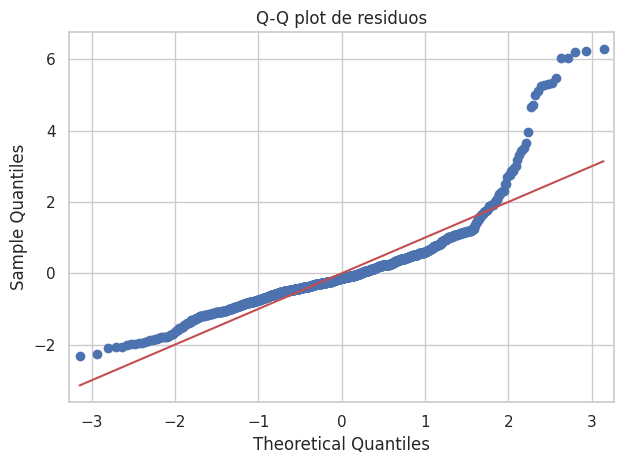

In [15]:
print("\n[4] Gráfico: Q-Q plot de residuos")

plt.figure(figsize=(8, 6))
qqplot(modelo.resid, line="s", fit=True)
plt.title("Q-Q plot de residuos")
plt.tight_layout()
plt.show()

El gráfico muestra desviaciones claras en la cola derecha, confirmando que existen observaciones con errores grandes; que suelen corresponder a países con adopción muy alta. Esto no implica necesariamente multicolinealidad, pero sí indica nuevamente que el modelo puede estar usando varias variables para explicar el mismo fenómeno estructural.


[5] Evaluación de independencia de errores
Durbin-Watson: 1.264


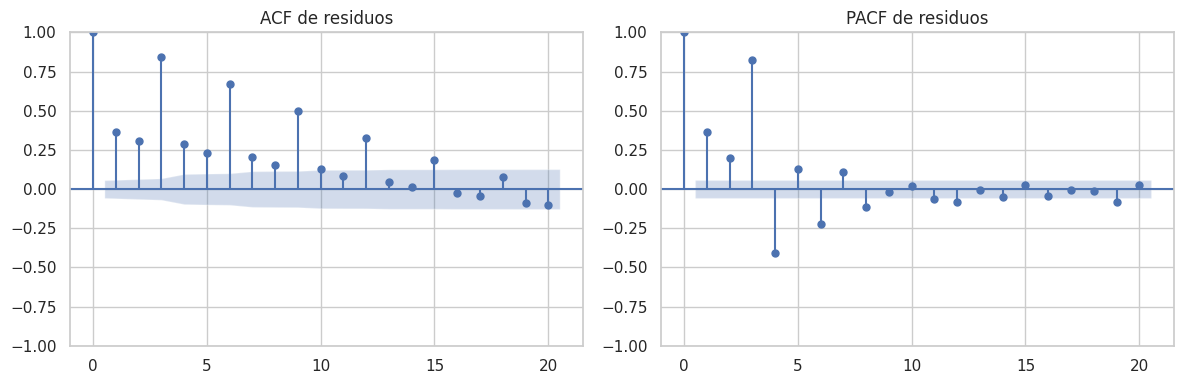

In [16]:
print("\n[5] Evaluación de independencia de errores")

dw = durbin_watson(modelo.resid)
print(f"Durbin-Watson: {dw:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(modelo.resid, ax=axes[0], lags=20)
axes[0].set_title("ACF de residuos")
plot_pacf(modelo.resid, ax=axes[1], lags=20)
axes[1].set_title("PACF de residuos")
plt.tight_layout()
plt.show()

Los primeros picos los interpreto como dependencia temporal en los residuos, como los datos son por país-año, la adopción de mercado sigue tendencias temporales, por lo que puede haber correlaciones en variables que evoucionen con el tiempo (O consideré algo mal con el tema de los dato por año)

In [17]:
print("\n[6] Evaluación de homocedasticidad")

bp_test = het_breuschpagan(modelo.resid, modelo.model.exog)
bp_labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]

for nombre, valor in zip(bp_labels, bp_test):
    print(f"{nombre}: {valor:.4f}")


[6] Evaluación de homocedasticidad
LM Statistic: 302.5321
LM-Test p-value: 0.0000
F-Statistic: 50.1850
F-Test p-value: 0.0000



[7] Gráfico: coeficientes del modelo


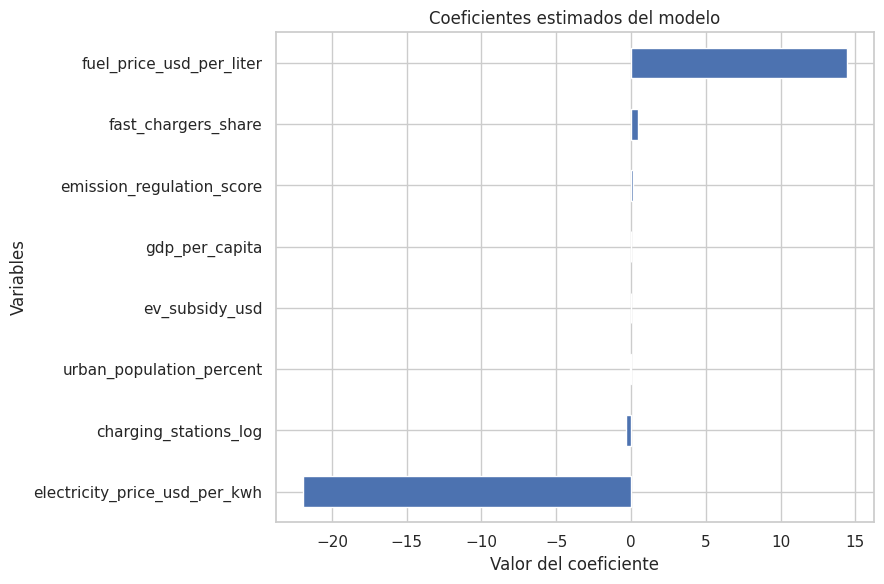

In [18]:
print("\n[7] Gráfico: coeficientes del modelo")

coeficientes = modelo.params.drop("const").sort_values()

plt.figure(figsize=(9, 6))
coeficientes.plot(kind="barh")
plt.title("Coeficientes estimados del modelo")
plt.xlabel("Valor del coeficiente")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [19]:
print("\n[8] Evaluación de multicolinealidad (VIF)")

vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif_data)


[8] Evaluación de multicolinealidad (VIF)
                        Variable        VIF
0                          const  39.188214
1                 gdp_per_capita   2.634913
2                 ev_subsidy_usd   1.648784
3       fuel_price_usd_per_liter   4.965510
4  electricity_price_usd_per_kwh   2.168345
5          charging_stations_log   7.759256
6            fast_chargers_share   3.892593
7      emission_regulation_score  11.523735
8       urban_population_percent   1.498252



[10] Panel general de diagnóstico del modelo


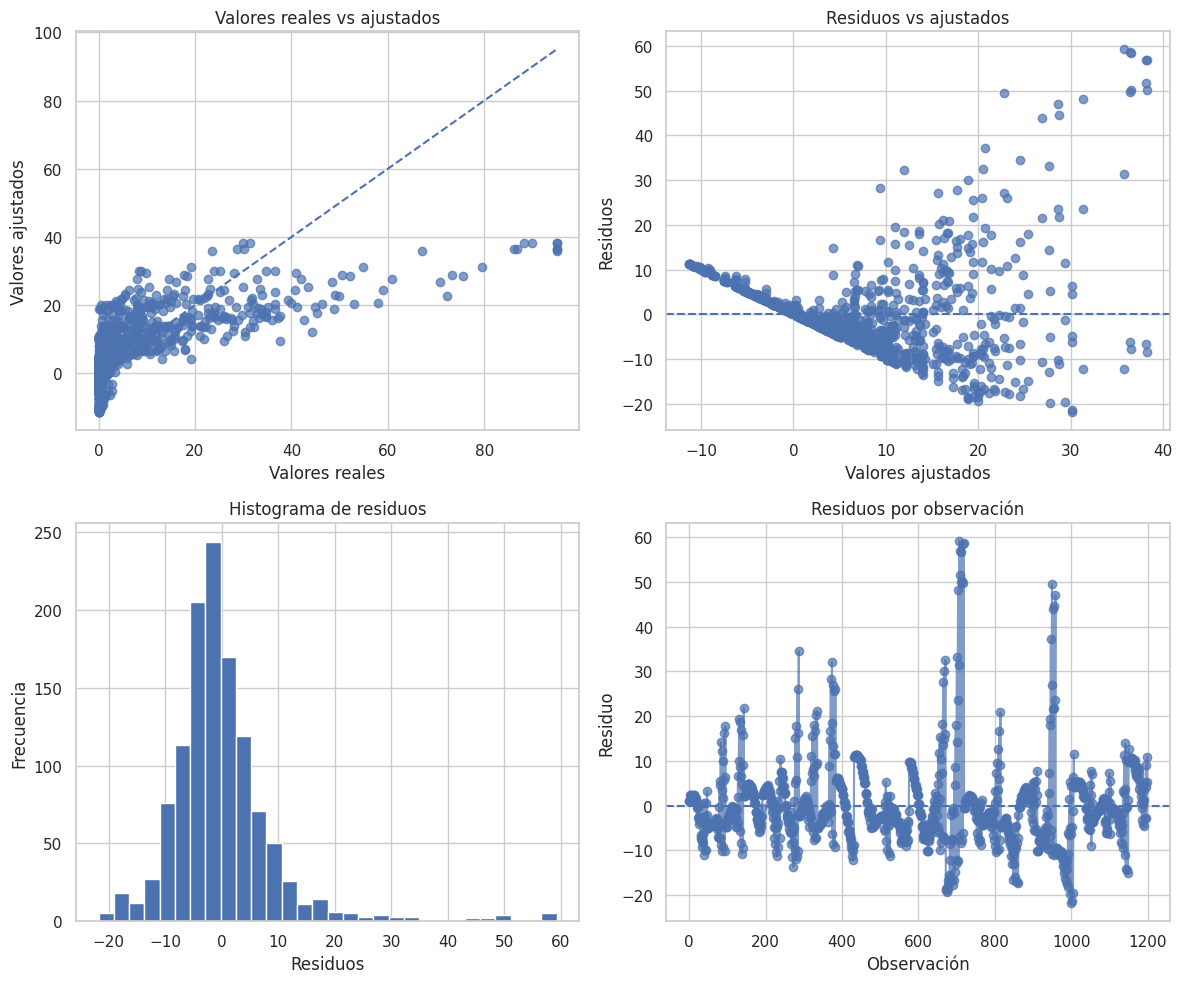

In [21]:
print("\n[10] Panel general de diagnóstico del modelo")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Reales vs ajustados
axes[0, 0].scatter(y, modelo.fittedvalues, alpha=0.7)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
axes[0, 0].set_title("Valores reales vs ajustados")
axes[0, 0].set_xlabel("Valores reales")
axes[0, 0].set_ylabel("Valores ajustados")

# Residuos vs ajustados
axes[0, 1].scatter(modelo.fittedvalues, modelo.resid, alpha=0.7)
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_title("Residuos vs ajustados")
axes[0, 1].set_xlabel("Valores ajustados")
axes[0, 1].set_ylabel("Residuos")

# Histograma de residuos
axes[1, 0].hist(modelo.resid, bins=30)
axes[1, 0].set_title("Histograma de residuos")
axes[1, 0].set_xlabel("Residuos")
axes[1, 0].set_ylabel("Frecuencia")

# Residuos por orden
axes[1, 1].plot(modelo.resid.values, marker="o", linestyle="-", alpha=0.7)
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].set_title("Residuos por observación")
axes[1, 1].set_xlabel("Observación")
axes[1, 1].set_ylabel("Residuo")

plt.tight_layout()
plt.show()

In [23]:
import numpy as np

df["charging_stations_log"] = np.log1p(df["charging_stations"])

In [24]:
print("\n[1] Matriz de correlación entre variables explicativas")

variables = [
    "gdp_per_capita",
    "ev_subsidy_usd",
    "fuel_price_usd_per_liter",
    "electricity_price_usd_per_kwh",
    "charging_stations",
    "fast_chargers_share",
    "emission_regulation_score",
    "urban_population_percent"
]

corr_matrix = df[variables].corr()

print(corr_matrix.round(3))


[1] Matriz de correlación entre variables explicativas
                               gdp_per_capita  ev_subsidy_usd  \
gdp_per_capita                          1.000           0.053   
ev_subsidy_usd                          0.053           1.000   
fuel_price_usd_per_liter                0.524           0.044   
electricity_price_usd_per_kwh           0.401           0.163   
charging_stations                      -0.086          -0.036   
fast_chargers_share                     0.153           0.283   
emission_regulation_score               0.663           0.300   
urban_population_percent                0.529           0.083   

                               fuel_price_usd_per_liter  \
gdp_per_capita                                    0.524   
ev_subsidy_usd                                    0.044   
fuel_price_usd_per_liter                          1.000   
electricity_price_usd_per_kwh                     0.647   
charging_stations                                 0.001   
fast

### Variables candidatas a revisión o posible eliminación

A partir del análisis exploratorio del modelo de regresión y de la revisión de los coeficientes estimados, es posible identificar algunas variables que podrían estar aportando **información redundante o poco significativa** al modelo. En particular, se observa que ciertas variables presentan coeficientes muy cercanos a cero o representan fenómenos estructurales que probablemente estén relacionados entre sí. Esto sugiere que algunas de ellas podrían estar explicando **aspectos similares del contexto económico o institucional de los países**, lo que puede generar multicolinealidad y reducir la interpretabilidad del modelo.

En primer lugar, variables como **`gdp_per_capita`** y **`urban_population_percent`** suelen estar estrechamente relacionadas, ya que los países con mayores niveles de desarrollo económico tienden también a presentar mayores niveles de urbanización. En este sentido, ambas variables podrían estar capturando el mismo fenómeno subyacente asociado al nivel de desarrollo del país. Por esta razón, mantener ambas en el modelo podría no aportar información adicional significativa, y una de ellas podría considerarse candidata a ser eliminada en etapas posteriores del análisis. De manera similar, la variable **`emission_regulation_score`** puede estar vinculada con otros factores institucionales o económicos incluidos en el modelo, como los subsidios a vehículos eléctricos o el nivel de desarrollo económico. Los países con mayores ingresos y mayor capacidad institucional suelen implementar regulaciones ambientales más estrictas, por lo que esta variable podría estar correlacionada con otras variables explicativas ya presentes en el modelo. Por otro lado, dentro del grupo de variables relacionadas con la infraestructura de carga, **`charging_stations`** y **`fast_chargers_share`** también podrían estar capturando dimensiones similares del desarrollo de la infraestructura para vehículos eléctricos. Aunque una mide el número total de estaciones y la otra la proporción de cargadores rápidos, ambas reflejan el grado de disponibilidad de infraestructura para la recarga de vehículos eléctricos en un país. Si estas variables presentan una correlación elevada, podría ser conveniente conservar únicamente aquella que aporte mayor capacidad explicativa al modelo.

En conjunto, estas observaciones sugieren que variables como **`urban_population_percent`**, **`gdp_per_capita`**, **`emission_regulation_score`** y potencialmente una de las variables de infraestructura de carga podrían considerarse **candidatas a revisión o eliminación** en etapas posteriores del análisis.

### Conclusión

El análisis multivariado sugiere que el modelo logra explicar parte de la variabilidad en la adopción de vehículos eléctricos, aunque se observan indicios de que algunas variables podrían estar aportando información similar. En particular, factores relacionados con el desarrollo económico, la infraestructura de carga y las políticas ambientales pueden presentar relaciones entre sí, lo que podría generar problemas de multicolinealidad en el modelo.


[2] Heatmap de correlación entre variables


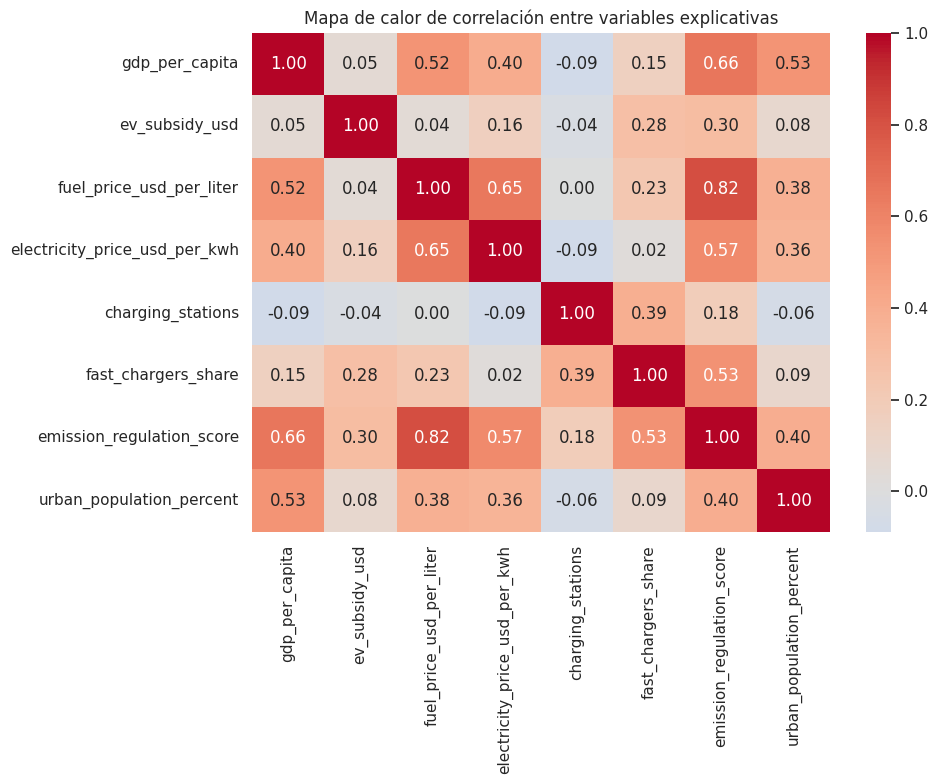

In [25]:
print("\n[2] Heatmap de correlación entre variables")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Mapa de calor de correlación entre variables explicativas")
plt.tight_layout()
plt.show()